In [1]:
%load_ext autoreload
%autoreload 2

import numpy as np
import matplotlib.pyplot as plt
from itertools import product

from algorithms import *
from plots import *
from utilities import *

## SDRG ALGORITHM INITIALIZATION

In [ ]:
# Global variables
M      = 5000
N      = 2048
ZETA   = 1
H0     = 0
DEBUG  = False

N_p = 10
gamma_list = [0.5, 0.93, 1, 1.25, 1.5]
for gamma_0 in gamma_list:
    omega_list, decimations = RandomIsing_SDRG(M, N, gamma_0, H0, J_0=1, zeta=ZETA, n_cores=-1, DEBUG=False)
    save_results(decimations, "decimations", gamma_0, H0, N, M, idx=0)
    save_results(omega_list, "excitations", gamma_0, H0, N, M, idx=0)

Estimation of the cross-over region position:

In [ ]:
M     = 100
N     = 2048
ZETA  = 1
H0    = np.exp([-3*k for k in range(2, 6)])

Np = 15
interpol = np.array([np.sqrt(k) / np.sqrt(Np) for k in range(0, Np+1)])
interpol = np.concatenate([0.5*interpol, 1 - interpol[::-1]*0.5])
gamma_list = 0.85 + interpol*(1.05-0.85)

#plt.scatter(gamma_list, [1]*gamma_list.shape[0])
for h0, gamma0 in product(H0, gamma_list):
    omega_list, decimations = RandomIsing_SDRG(M, N, gamma0, h0, J_0=1, zeta=ZETA, n_cores=3, DEBUG=False)
    save_results(omega_list, "excitations", gamma0, h0, N, M, 0)
    

Scaling behaviour in vicinity of the IDFP

In [ ]:
M      = 3
N      = 128
ZETA   = 1
H0     = 0
GAMMA0 = 0.93

omega_list, decimations, mm = RandomIsing_SDRG(M, N, GAMMA0, H0, 1, ZETA, 1)


STARTED STRONG-DISORDER RG ALGORITHM FOR ISING CHAIN (GAMMA0=0.93 - H0=0 - N=128 - M=3)
---Executing SD renormalization algorithm on chain #0---
---SDRG algorithm executed on chain #0---
---Executing SD renormalization algorithm on chain #1---
---SDRG algorithm executed on chain #1---
---Executing SD renormalization algorithm on chain #2---
---SDRG algorithm executed on chain #2---

SDRG ALGORITHM EXECUTED WITH TIME 0.09291291236877441 (s).


0.0005345557638375992

In [77]:
from glob import glob

t = glob("crossover-region/*")
len(t)

120

## SDRG Fixed points

Reading from decimations/*


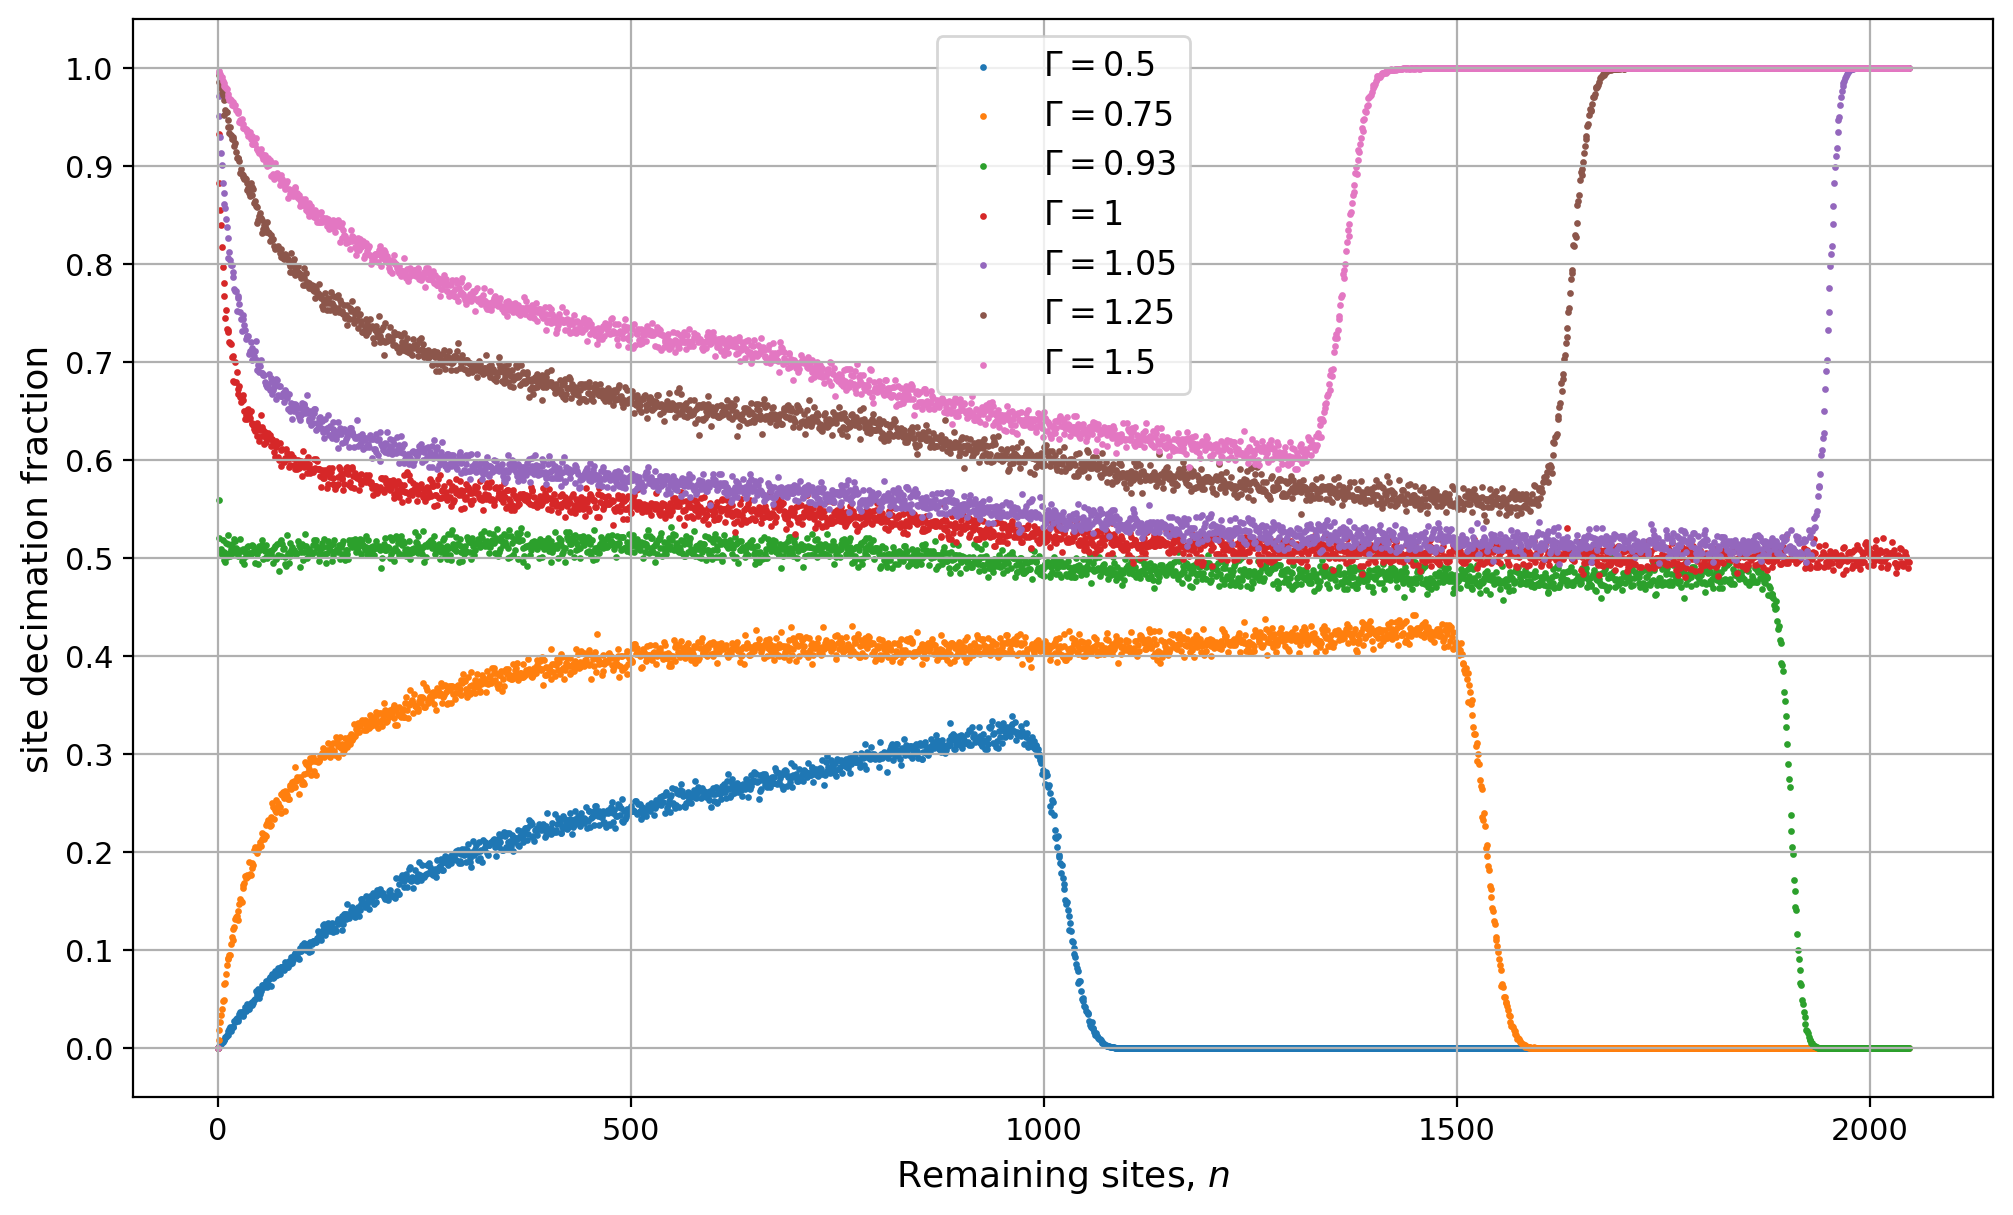

In [442]:
decimations_res, gamma_list = read_results("decimations")
plot_results("decimations", decimations_res, N, gamma_list, H0)

## Properties of the RG-flow

Reading from excitations/*


/Users/raffaele/Documents/Visual Studio/PhysicsOfData/Semester_3/Quantum_Info_and_Computing/QIAC2-project/plots.py:57: RuntimeWarning: divide by zero encountered in log


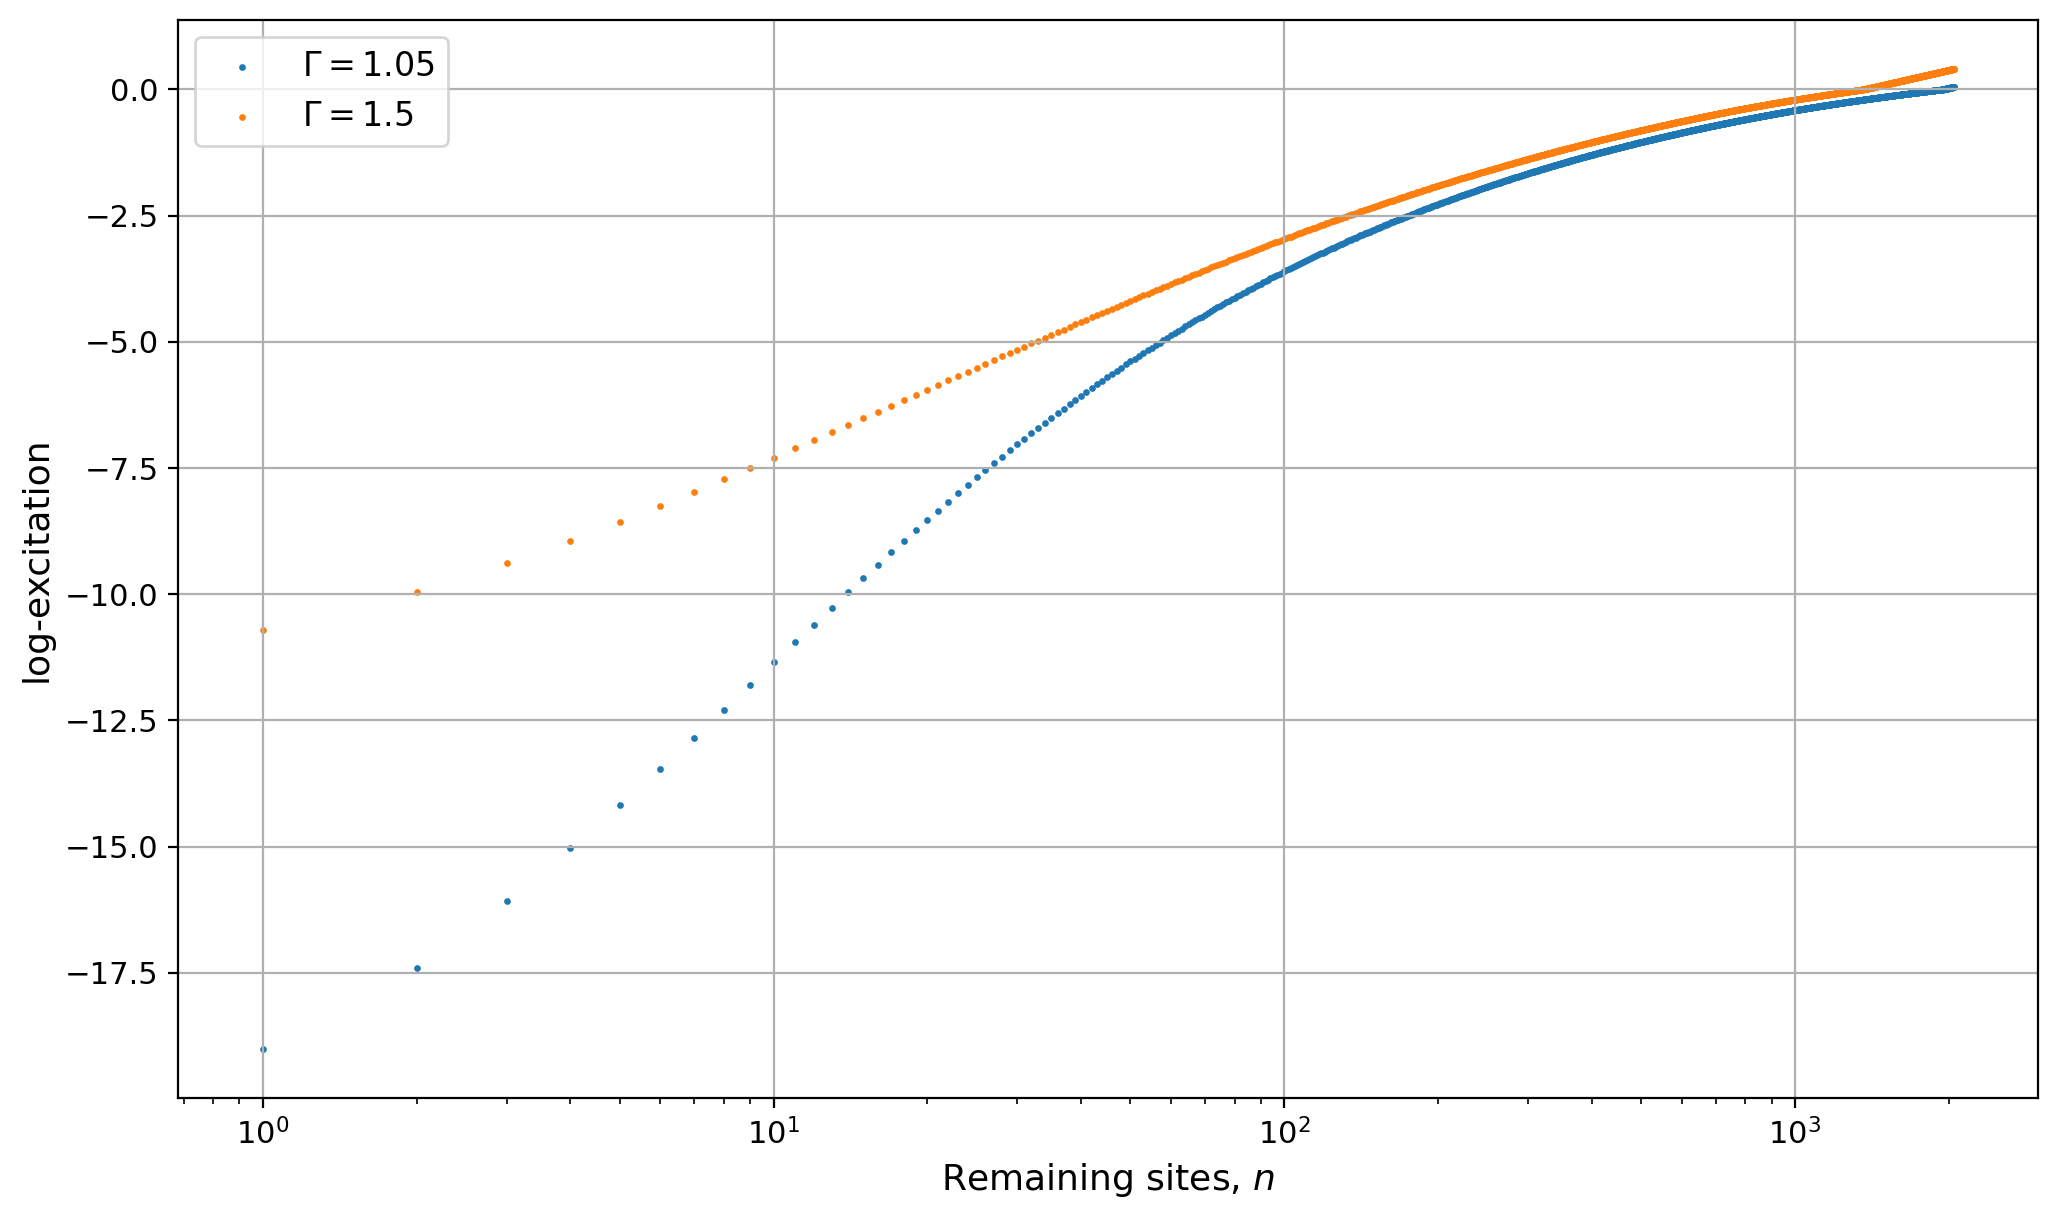

In [450]:
excitations, gamma_list = read_results("excitations")
plot_results("excitations", excitations, N, gamma_list, H0)

## Estimates for the position of the cross-over region

Reading from /Users/raffaele/Documents/Visual Studio/PhysicsOfData/Semester_3/Quantum_Info_and_Computing/QIAC2-project/crossover-region2/*


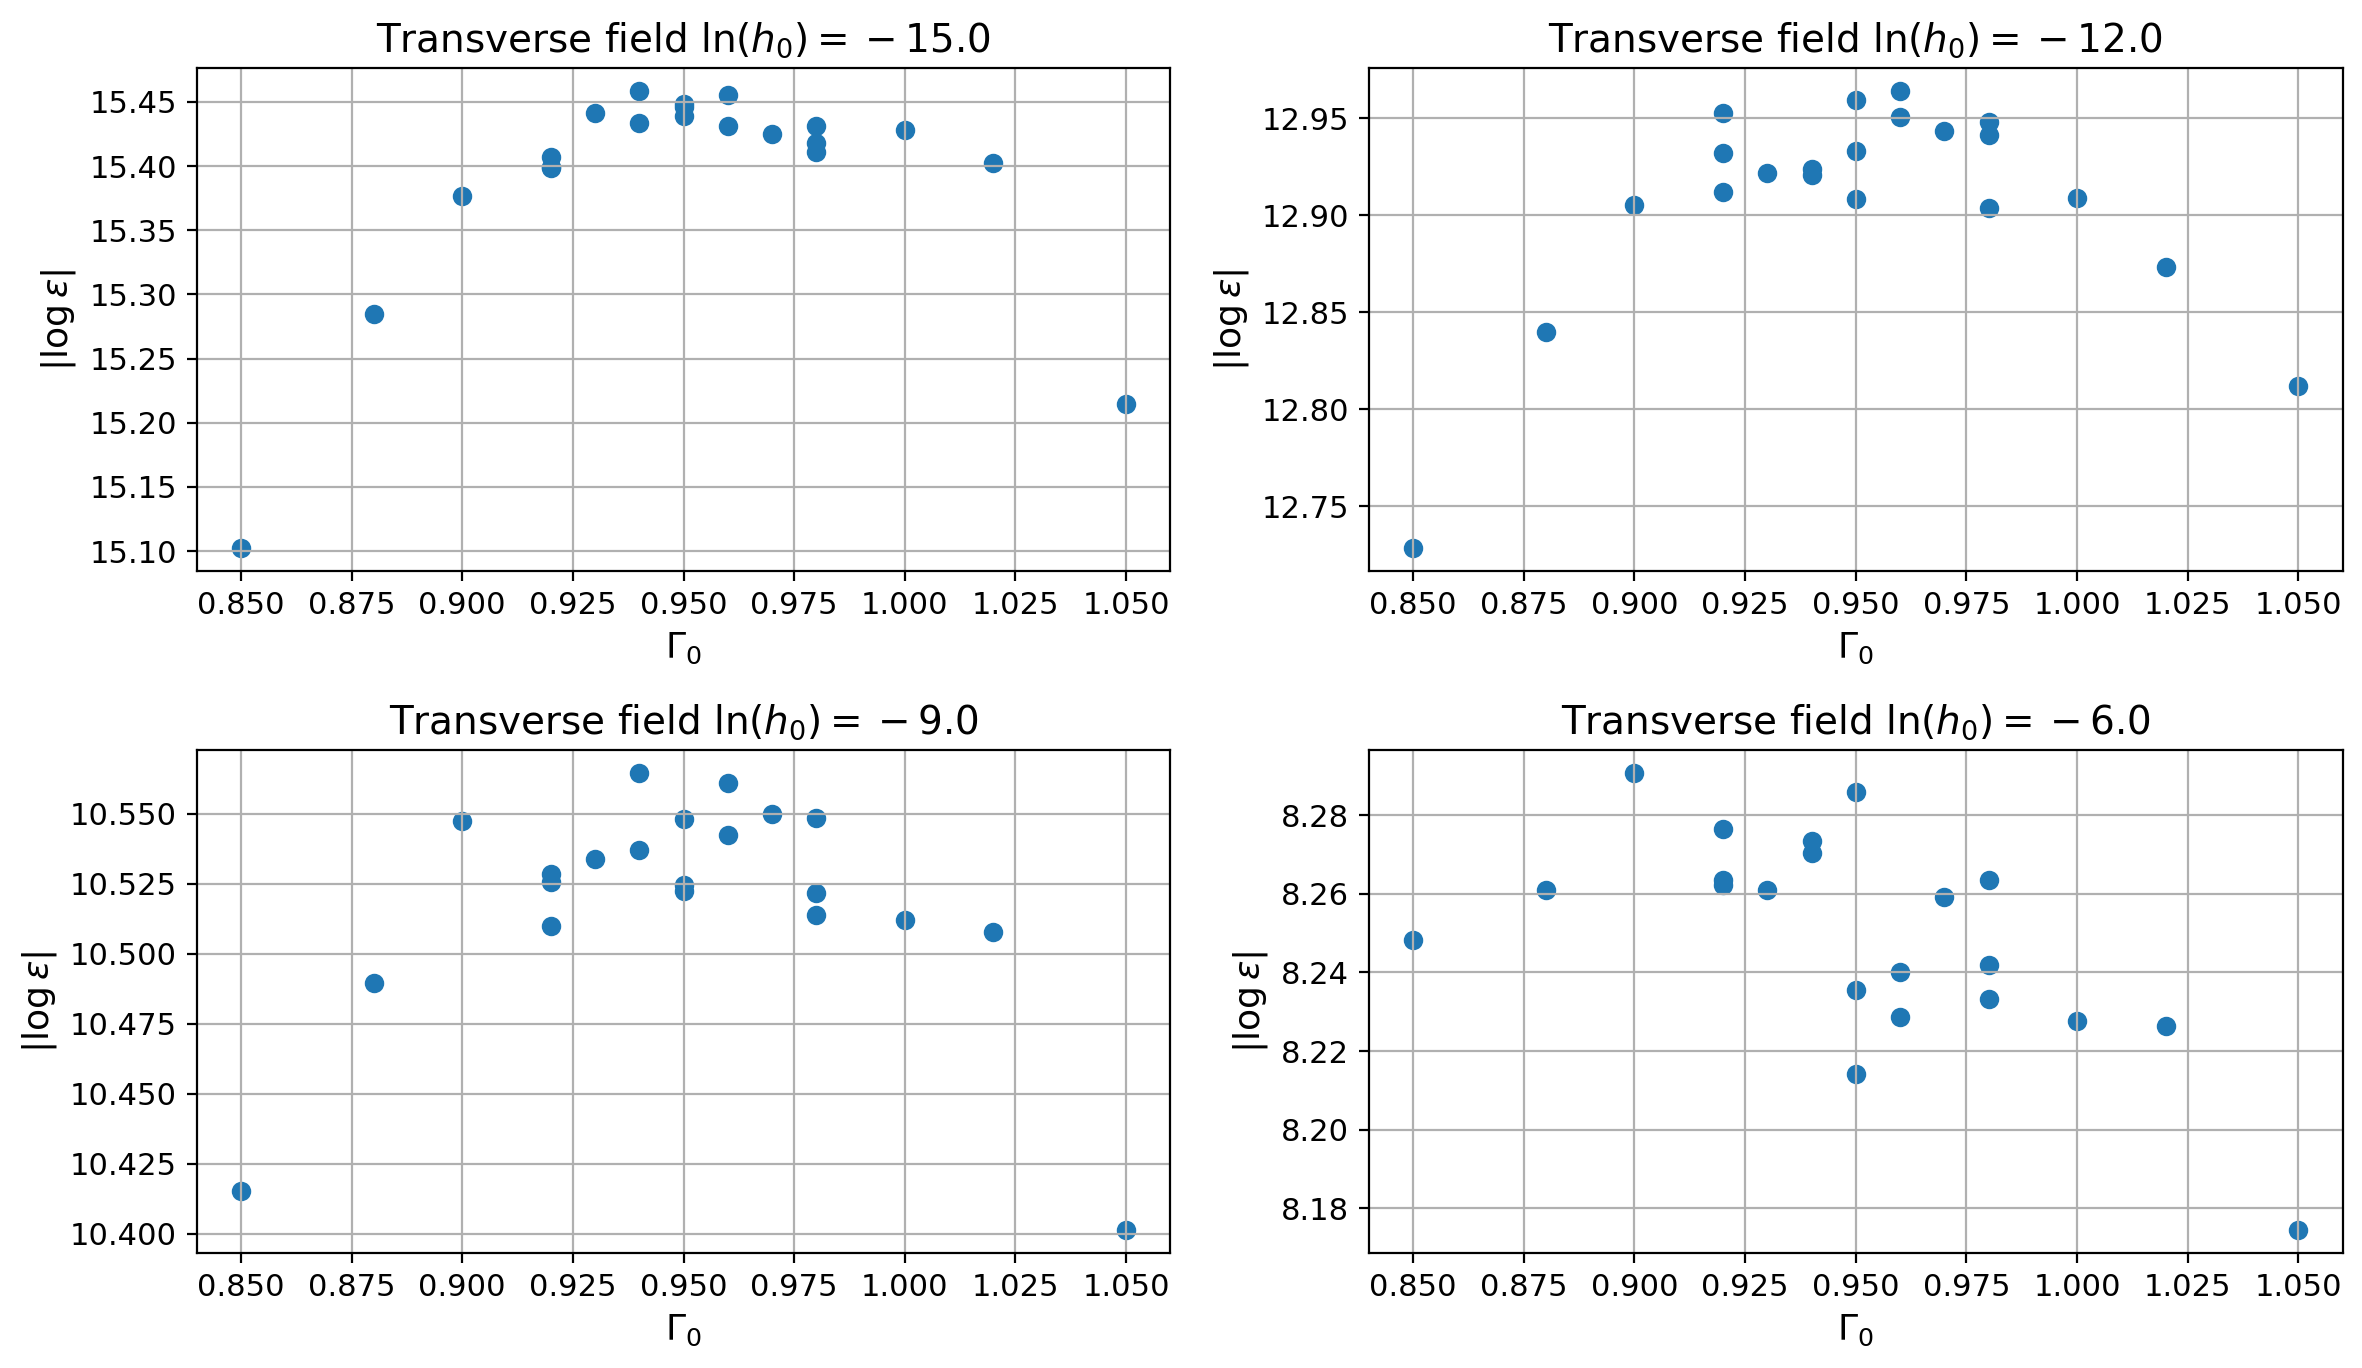

In [ ]:
'''
----------------------------------------------------------
Values of gamma0 and H0 are generated with:

    H0    = np.exp([-3*k for k in range(2, 6)])

    interpol = np.array([np.sqrt(k) / np.sqrt(Np) for k in range(0, Np+1)])
    interpol = np.concatenate([0.5*interpol, 1 - interpol[::-1]*0.5])
    gamma_list = 0.88 + interpol*(1.02-0.88)
----------------------------------------------------------
'''

omega, gamma, h = read_results("crossover-region2")
plot_critial_position(omega[-2, :], gamma, h)